## Context Engineering In Deep Agents 

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long running sessions. 

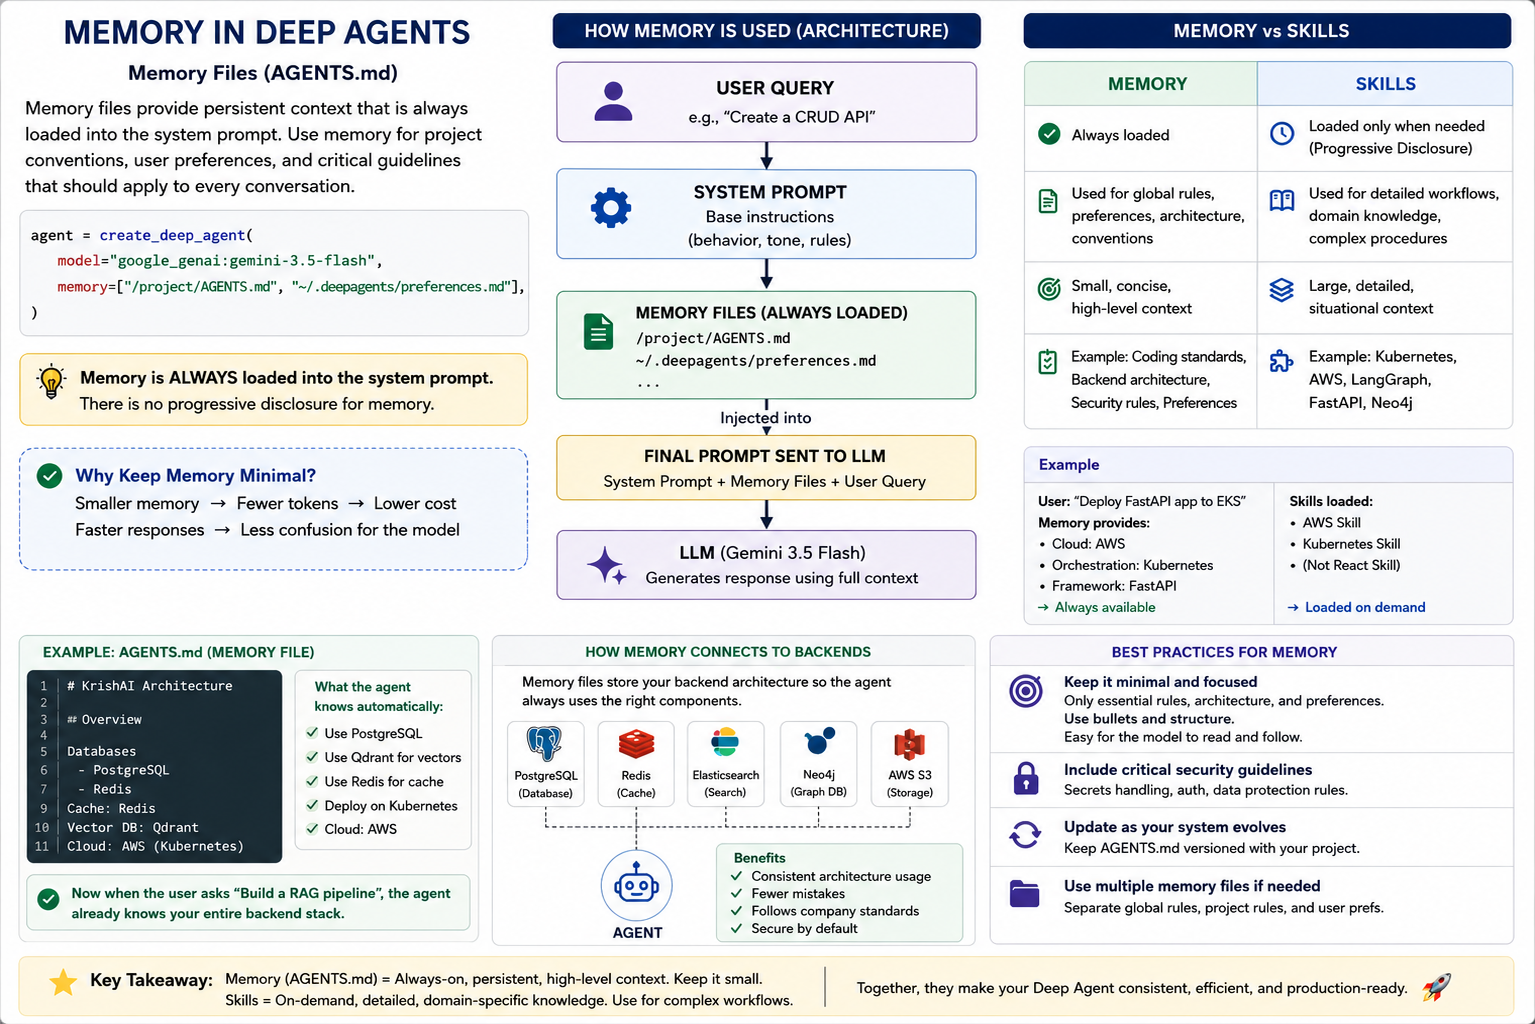

In [1]:
## Basic deep agent 
import os 
from dotenv import load_dotenv


os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Context Engineering - Input Context - System Prompt 

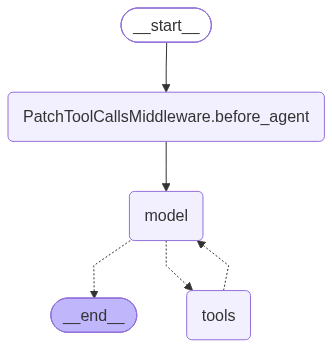

In [2]:
from deepagents import create_deep_agent 

agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics"
    )
)

agent 

In [3]:
result = agent.invoke({"messages": {"role": "user", "content": "What is deepagent?"}})

In [4]:
result 

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='21775a13-cbb8-460b-b2f9-3be9ce1d8844'),
  AIMessage(content='Based on current scientific and software engineering literature, **DeepAgent** generally refers to a class of artificial intelligence systems or open-source frameworks that combine **deep learning models** with **agent architectures** to enable autonomous decision-making and task execution. The term is used both as a broad research concept and as the name of specific software projects.\n\nHere is a breakdown of what DeepAgent typically entails:\n\n### 1. Core Concept\nIn AI research, a "Deep Agent" is an autonomous entity that uses deep neural networks (DNNs) or large language models (LLMs) as its "brain" to perceive environments, reason about goals, and take actions. Unlike traditional rule-based agents, deep agents learn strategies through:\n* **Reinforcement Learning (RL):** Learning optimal behaviors via trial-and-erro

### Context Engineering with `AGENTS.md`

Instead of hardcoding a long string into your `system_prompt`, we keep the agent's operating context in a separate `AGENTS.md` file. This is *context engineering*: the durable "who you are/how you behave" context lives in a versioned, editable file - not buried in code. 

In [5]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [6]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer= MemorySaver()

### Backends: Where the Agent's Files / Memory Live

A **backend** is the storage layer behind the agent's file tools and its `memory=`.

The same agent code can use different backends depending on how long the data needs to persist:

| Backend | Lives in | Survives across | Use it when... |
|---|---|---|---|
| **StateBackend** (default) | LangGraph state (the `files` channel) | One thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | Everything — it's just files | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **All threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [8]:
agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    checkpointer=MemorySaver()
    # no backend, no memory =, no files = 
)

result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

Based on the project guide you've provided, I am a **Deep Agent** — an agent designed for complex, multi-step, long-horizon tasks, built on LangGraph.

## Who I Am

I'm not a simple tool-calling loop. I'm architected around **four pillars**:

| Pillar | Purpose |
|---|---|
| **Planning** | I use a `write_todos` tool to break tasks into steps and track progress (`pending` → `in_progress` → `completed`) |
| **File System (Context Offloading)** | I use `ls`, `read_file`, `write_file`, `edit_file` to store large intermediate results outside the context window |
| **Subagents** | I can spawn specialized child agents with isolated context via the `task` tool |
| **System Prompt** | I follow detailed instructions that teach me *when* and *how* to use the above capabilities |

## What I Should Follow

Per **Section 4 — Operating Guidelines**:

1. **Plan first** — For any task with more than ~2 steps, call `write_todos` before starting work, and keep statuses updated as I go.
2. **Offload aggre

In [9]:
# Default backend (no backend= passed) 
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)


agent=create_deep_agent(
    model="groq:qwen/qwen3.6-27b",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [10]:

from deepagents.backends.utils import create_file_data

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)



Based on my memory file (`/projects/AGENTS.md`), here's who I am:

## Identity

I'm a **Deep Agent** — an agent designed for complex, multi-step, long-horizon tasks built on top of **LangGraph**. I'm not just a simple tool-calling loop; I have several architectural capabilities:

## What's in My Memory

The memory file describes my four core pillars:

1. **Planning** — I use a `write_todos` tool to break tasks into steps and track progress
2. **File System (Context Offloading)** — I have virtual file tools (`ls`, `read_file`, `write_file`, `edit_file`) to store large intermediate results outside the chat context window
3. **Subagents** — I can spawn specialized child agents with isolated contexts for parallel exploration
4. **Detailed System Prompt** — I follow carefully engineered instructions about when and how to use my capabilities

## My Operating Guidelines

My memory instructs me to:
- **Plan first** for tasks with more than ~2 steps
- **Offload aggressively** — write raw resear

In [11]:
# StoreBackend: persistent, cross-thread memory 
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.

from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# seed durable memory into the store once, Namespace + key identify the file. 
store.put(("memories",), "AGENTS.md", create_file_data(agents_md)) # this is basically saying create a store named memories and inside of it the key value pair are those two things 

store_agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b", 
    backend=StoreBackend(store = store, namespace=lambda rt: ("memories")), 
    memory=["/projects/AGENTS.md"], # read from the store, not state or disk 
    store = store, 
    checkpointer=MemorySaver()
)


# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke({
    "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],}, 
    config = {"configurable": {"thread_id": "store-demo-1"}}
)

print(result["messages"][-1].content)

## What's in my memory?

Currently, my memory is **empty**. There are no saved preferences, instructions, or learned information stored yet. This is a fresh start!

## Who am I?

I'm an AI assistant with the following capabilities:

- **Filesystem access**: I can list directories, read/write/edit/delete files, search for files using glob patterns, and grep for text across files.
- **Subagents**: I can launch helper agents to handle complex, multi-step tasks in parallel.
- **Learning & memory**: I can save useful information, preferences, and patterns to memory files so I remember them in future conversations.
- **Conversational assistance**: I can answer questions, write code, analyze text, and help with a wide variety of tasks.

I'm designed to be helpful, transparent, and adaptive. As we work together, I'll learn your preferences and update my memory accordingly so I can serve you better over time.

Is there anything specific you'd like me to help with, or any preferences you'd like 

In [12]:
# FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.

from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver


# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.

fs_agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b",
    backend=FilesystemBackend(root_dir = 'projects', virtual_mode=True), 
    memory = ["AGENTS.md"],                                # -> projects/AGENTS.md
    checkpointer=MemorySaver()
)

# Fresh thread_id so Memory Middleware reloads (memory loads once per thread)
result = fs_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What's in your memory ? who are you ? "
    }]}, 
    config = {"configurable": {"thread_id": "fs-demo2"}}
)

print(result["messages"][-1].content)


## Who I Am

I'm a **Deep Agent** — an advanced AI agent built on top of **LangGraph** (a framework by LangChain), designed for complex, multi-step, long-horizon tasks. I'm inspired by applications like Claude Code, Deep Research, and Manus.

## What's In My Memory

My memory consists of a single context file (`AGENTS.md`) that describes:

### 1. **My Architecture** — I'm built on four pillars:
| Pillar | Description |
|---|---|
| **Planning** | I use a todo-list tool (`write_todos`) to break tasks into steps and track progress |
| **File System** | I have virtual file tools (`ls`, `read_file`, `write_file`, `edit_file`) to offload large data out of my context window |
| **Subagents** | I can spawn specialized child agents with isolated contexts to delegate work |
| **System Prompt** | I follow a detailed, carefully engineered set of instructions |

### 2. **How I'm Built** — I'm created using the `create_deep_agent` function from the `deepagents` library, with a chat model (e.g., Anth

In [13]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)



# LLM Gateways

**LLM Gateways** are middleware services that sit between your application and one or more Large Language Model (LLM) providers. They act as a unified entry point for routing, managing, and optimizing requests to LLMs.

## Key Capabilities

| Capability | Description |
|---|---|
| **Model Agnosticism** | Switch between providers (OpenAI, Anthropic, Google, etc.) without changing application code. |
| **Load Balancing** | Distribute requests across multiple models or replicas for better performance and cost. |
| **Fallback & Failover** | If one provider fails or rate-limits, automatically retry with another. |
| **Caching** | Cache responses to identical prompts, reducing latency and API costs. |
| **Rate Limiting & Quotas** | Enforce usage limits per user, team, or application. |
| **Logging & Observability** | Centralized tracking of prompts, completions, token usage, latency, and costs. |
| **Security** | Mask sensitive data, enforce content filters, and manage API ke

### Skills in Deep Agents 

Skills are reusable agent capabilities that provide specialized workflows and domain knowledge. You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent's performance on LangChain ecosystem tasks, see the LangChain Skills repository. Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can tell 

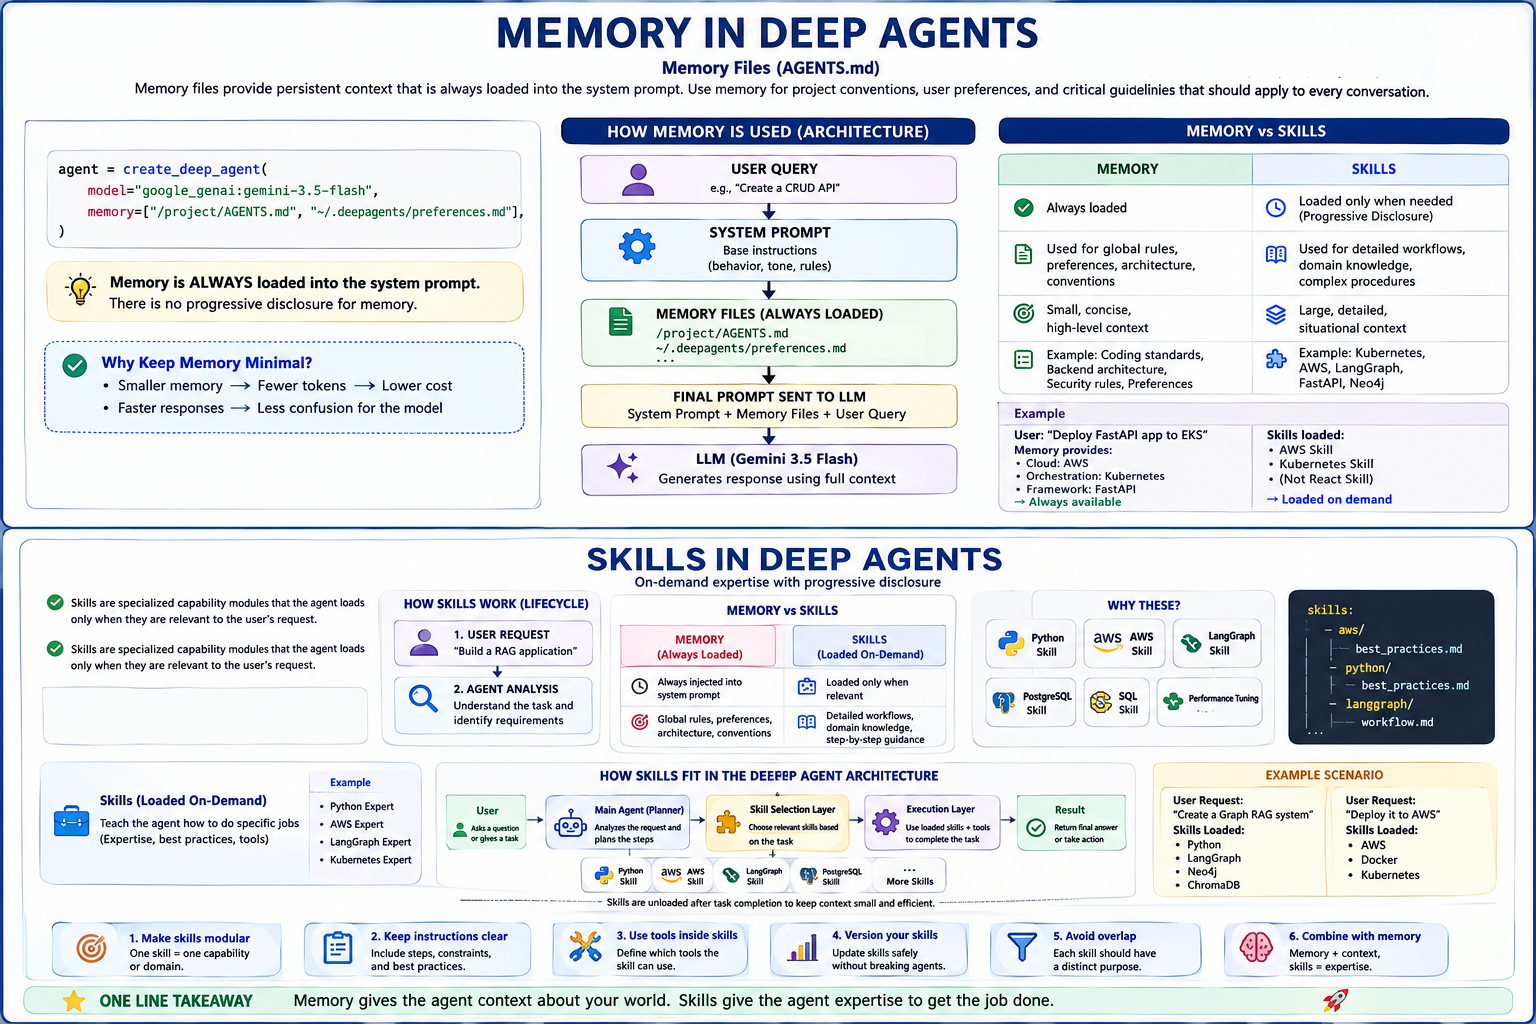